# Explainer Notebook Social Data Visualization Final Project

This notebook contains the steps of our analysis, preprocessing, visualization development, and design decisions used for our final project website. The goal of our project was to explore how Melbourne’s pedestrian activity changes throughout the week and to see what these movement patterns reveal about the city’s culture, transportation habits, and work week vs weekend patterns.

Website: https://bottemiller.github.io/social-data-final-project/


# 1. Motivation

## What is the dataset?

Our project uses the City of Melbourne Pedestrian Counting System Dataset, an open dataset containing hourly pedestrian counts collected from more than 60 sensors located throughout Melbourne’s Central Business District (CBD). The data was specifically from 2025. The dataset originally included:
- ID number
- Hourly pedestrian counts in multiple directions
- Total hourly pedestrian count
- Dates
- Coordinates
- Sensor names

The dataset captures how people move throughout the city over time and allowed us to understand how work routines, nightlife, shopping behavior, tourism, and transportation patterns impact the city's streets.

## Why did you choose this/these particular dataset(s)?

We chose the Melbourne pedestrian dataset because pedestrian movement shows how a city changes throughout an individual day, as well as throughout a week. As exchange students, we were interested in understanding Melbourne’s social culture and comparing its rhythm to cities we were more familiar with, such as Copenhagen and Houston. We have a friend from Melbourne, which also motivated us to find out more about the city and get a grasp on the social/ urban culture of the city. The dataset stood out because it contains strong temporal and spatial components that support the understanding of Melbourne's weekly culture through visualization. The data shows work routines, nightlife, tourism, transportation habits, and social behavior.

## What was your goal for the end user's experience?

Our goal for the end user experience was to create a website that was interesting and accessible for the average reader who doesn't have. a technical background. We wanted the website to feel more like an interactive story that shows users how Melbourne evolves throughout the week. Through interactive charts and animations, we wanted readers to be able to understand the urban and social culture of Melbourne and feel like they know the ryhthm of the city. We also wanted the user to be able to customize the experience a bit, allowing them to investigate certain streets that captrured their interest. To do this, we added filter and zoom features.

# 2. Basic Statistics and Dataset Understanding

## Data Cleaning and Preprocessing

Before beginning the visual analysis, we preprocessed the dataset to make it easier to analyze and visualize. An hour category column was created to determine what time of day (morning rush, midday, evening rush, and night). In addition, we made a new column of day type to show if the day was a weekday or weekend since this was one of the main points of analysis. We hoped to use this column to compare work centered movement patterns with leisure activities. Some visualizations focused only on the busiest or most representative sensors to reduce visual clutter and make the major trends easier to interpret. Thus, we tended to only use the 5 sensors with the most data. Finally, seperate latitude and longitude columns were made. From here, we were ready to continue with the projec.t Our final processed dataset included the following columns: 
 - ID: data point identifier
 - Location_ID: where the sensor was
 - Sensing_Date: data of recording pedestrian passing
 - HourDay: hour the passing occured
 - Direction_1: movement one way from sensor
 - Direction_2: movement in opposite way from sensor
 - Total_of_Directions: total between direction 1 and 2
 - Sensor_Name: name of sensor
 - Location: coordinates of sensor location
 - Day_Name: day of the week	
 - Day_Type: weekday or weekend
 - Hour_Category: morning rush, midday, evening rush, night
 - Latitude: coordinate
 - Longitude: coordinate

See more on the data processing code in the appendix section Data Processing.

Some important initial data analysis plots are included below as well as introductory statistics on the dataset. We initially wanted to understand what information the dataset gave us, and how we could use it to understand the urban patterns of Melbourne. We decided that the direction data was too vague and that there wasn't much to do with individual directions, so we instead focused on total pedestrian counts. We also checked to see if there were any null entries, which there weren't. The average amount of pedestrians that passed by a sensor at an hour was 382 people. This had a very high standard deviation, showing that the pedestrian count really depended on sensor location. Some got a lot more passing people than others, which makes sense. This also supported our decision, which will be explained more later, to only include the 5 busiest sensors.

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pedestrian-counting-system-monthly-counts-per-hour (2).csv")

df["Sensing_Date"] = pd.to_datetime(df["Sensing_Date"])
df["Sensor_Name"] = df["Sensor_Name"].str.strip()

df.head()


,ID,Location_ID,Sensing_Date,HourDay,Direction_1,Direction_2,Total_of_Directions,Sensor_Name,Location,Day_Name,Day_Type,Hour_Category,Latitude,Longitude
0,40020250722,40,2025-07-22,0,2,6,8,Spr201_T,"-37.80999341, 144.97227587",Tuesday,Weekday,Night,-37.809993,144.972276
1,361320250710,36,2025-07-10,13,282,321,603,Que85_T,"-37.81652527, 144.96121062",Thursday,Weekday,Midday,-37.816525,144.961211
2,5820250525,5,2025-05-25,8,121,142,263,PriNW_T,"-37.81874249, 144.96787656",Sunday,Weekend,Morning Rush,-37.818742,144.967877
3,108620250502,108,2025-05-02,6,34,189,223,261Will_T,"-37.81295822, 144.95678789",Friday,Weekday,Morning Rush,-37.812958,144.956788
4,1851320250725,185,2025-07-25,13,761,975,1736,Eli197_T,"-37.81374643, 144.96276183",Friday,Weekday,Midday,-37.813746,144.962762


In [53]:
import pandas as pd

df = pd.read_csv("pedestrian-counting-system-monthly-counts-per-hour.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 749239 entries, 0 to 749238
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   749239 non-null  int64  
 1   Location_ID          749239 non-null  int64  
 2   Sensing_Date         749239 non-null  str    
 3   HourDay              749239 non-null  int64  
 4   Direction_1          749239 non-null  int64  
 5   Direction_2          749239 non-null  int64  
 6   Total_of_Directions  749239 non-null  int64  
 7   Sensor_Name          749239 non-null  str    
 8   Location             749239 non-null  str    
 9   Day_Name             749239 non-null  str    
 10  Day_Type             749239 non-null  str    
 11  Hour_Category        749239 non-null  str    
 12  Latitude             749239 non-null  float64
 13  Longitude            749239 non-null  float64
dtypes: float64(2), int64(6), str(6)
memory usage: 80.0 MB


,ID,Location_ID,HourDay,Direction_1,Direction_2,Total_of_Directions,Latitude,Longitude
count,7.492390e+05,749239.000000,749239.000000,749239.000000,749239.000000,749239.000000,749239.000000,749239.000000
mean,4.991340e+11,75.403058,11.853826,188.489704,193.591935,382.081639,-37.813123,144.959903
std,5.311002e+11,52.052626,6.774679,295.656437,307.024240,571.317404,0.006724,0.009435
min,1.020250e+09,1.000000,0.000000,0.000000,0.000000,0.000000,-37.825910,144.929734
25%,7.102025e+10,35.000000,6.000000,17.000000,18.000000,38.000000,-37.817940,144.953864
50%,2.522203e+11,63.000000,12.000000,76.000000,76.000000,157.000000,-37.814141,144.962762
75%,7.615203e+11,124.000000,18.000000,225.000000,232.000000,473.000000,-37.809993,144.966167
max,1.852320e+12,185.000000,23.000000,10099.000000,11085.000000,11113.000000,-37.794324,144.974677


## Top Sensor Locations

Before choosing which locations to highlight on the website, we needed to understand which sensors recorded the highest average pedestrian activity. The top sensor chart helped show the busiest locations in the dataset and helped us to focus on a smaller number of high activity areas. We also used the Pedestrian Counts Distribution which revealed the drastic difference in frequency of pedestrians at the busy vs quieter sensors. This step was important because showing every sensor would make the visualizations cluttered and difficult for a non technical audience to interpret. By focusing on the busiest sensors, the final website could tell a more direct story about the most active parts of Melbourne.

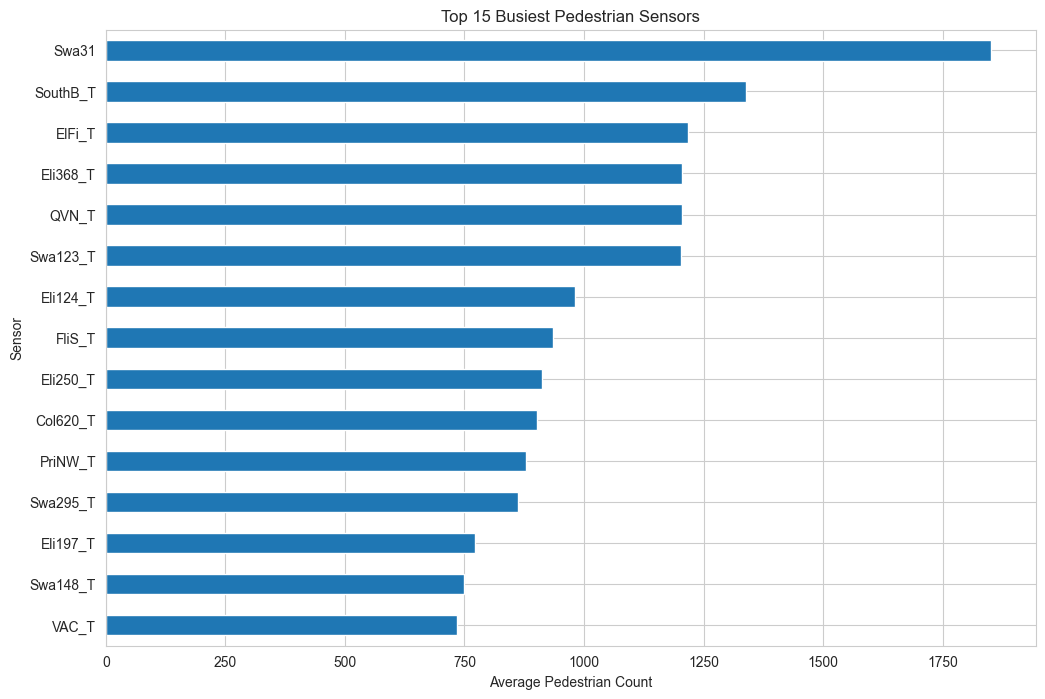

In [54]:
top_sensors = (
    df.groupby("Sensor_Name")["Total_of_Directions"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 8))
top_sensors.sort_values().plot(kind="barh")
plt.title("Top 15 Busiest Pedestrian Sensors")
plt.xlabel("Average Pedestrian Count")
plt.ylabel("Sensor")
plt.show()


## Distribution of Pedestrian Counts

The distribution chart helped us understand the overall shape of the pedestrian count data. Most observations have relatively low or moderate pedestrian counts, while a smaller number of observations show very high activity. This is expected in city sensor data because pedestrian movement is not evenly distributed across all locations and times. Certain locations and hours, such as commute periods, markets, and nightlife areas, naturally produce much higher counts. Understanding this distribution helped us avoid treating all sensors and times as equally representative.

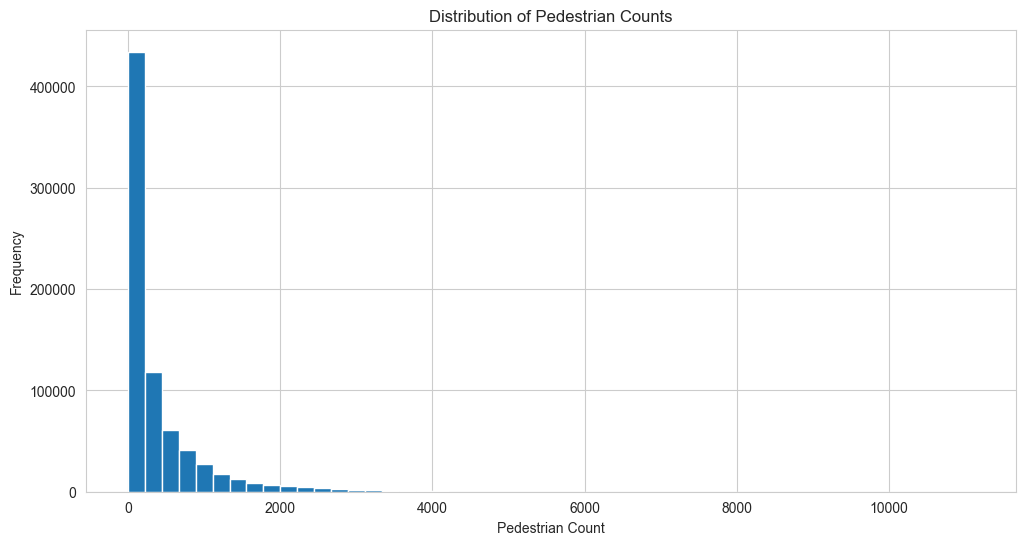

In [55]:
plt.figure(figsize=(12, 6))
plt.hist(df["Total_of_Directions"].dropna(), bins=50)
plt.title("Distribution of Pedestrian Counts")
plt.xlabel("Pedestrian Count")
plt.ylabel("Frequency")
plt.show()


# 3. Data Analysis

The primary focus of our analysis was understanding how pedestrian activity changes throughout the day and across different parts of the week. By examining hourly averages, we identified repeating cycles that showed commuting patterns, lunch activity, nightlife, and weekend changes. Comparing weekdays and weekends helped us to  understand the difference between work routines and more natural social movement patterns. We also examined transitional periods, such as Friday evenings, to observe how the city evolves throughout the week from work life to more relaxing weekends.

## Weekday vs Weekend Line Chart

The line chart was one of the most important visualizations because it clearly showed the difference between Melbourne’s weekday work patterns and its smoother weekend curve. During the week, the chart reveals the expected commuter pattern, with activity rising in the morning, increasing again around lunch, and peaking later in the afternoon for rush hour. On the weekend, the curve is less rigid and more gradual, which shows that Melbourne’s weekend movement is more leisure based. This visualization was important to consider in the analysis because it showed the drastic change in weekday versus weeke d behavior.

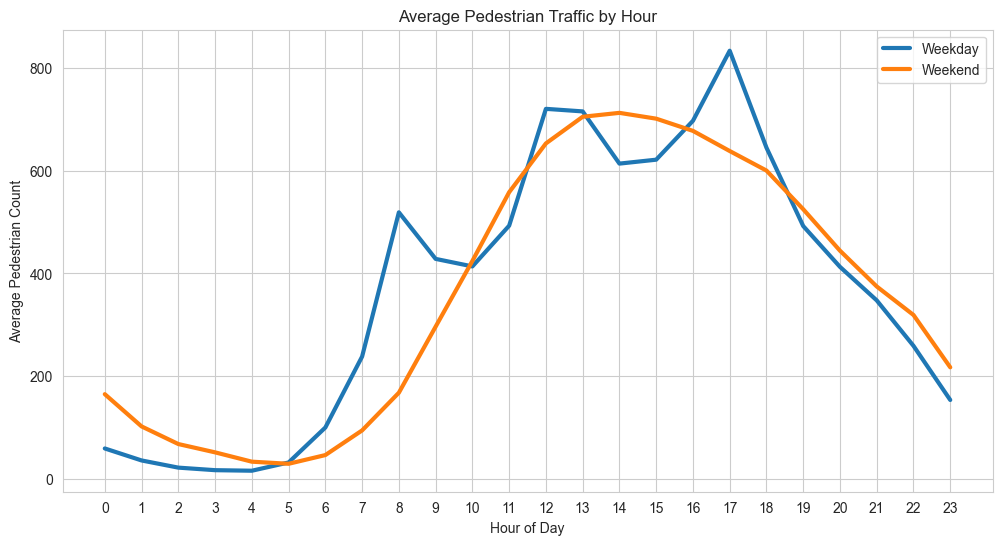

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pedestrian-counting-system-monthly-counts-per-hour (2).csv")
df["Sensing_Date"] = pd.to_datetime(df["Sensing_Date"])
df["Sensor_Name"] = df["Sensor_Name"].str.strip()

hourly_avg = (
    df.groupby(["Day_Type", "HourDay"])["Total_of_Directions"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for day_type, group in hourly_avg.groupby("Day_Type"):
    group = group.sort_values("HourDay")
    plt.plot(
        group["HourDay"],
        group["Total_of_Directions"],
        linewidth=3,
        label=day_type
    )

plt.title("Average Pedestrian Traffic by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Pedestrian Count")
plt.xticks(range(0, 24))
plt.legend()
plt.show()


## Day by Hour Heatmap

The heatmap was done in the initial data analysis because it allows us to compare all days of the week and all hours of the day at once.  This helped us identify Friday as a bridge between weekday and weekend behavior because Friday evening activity remains stronger than most other weeknights. It also made the weekend afternoon activity easier to see. In the website version, we limited the heatmap to the busiest representative areas so that users would not be overwhelmed by too many sensor locations at once.

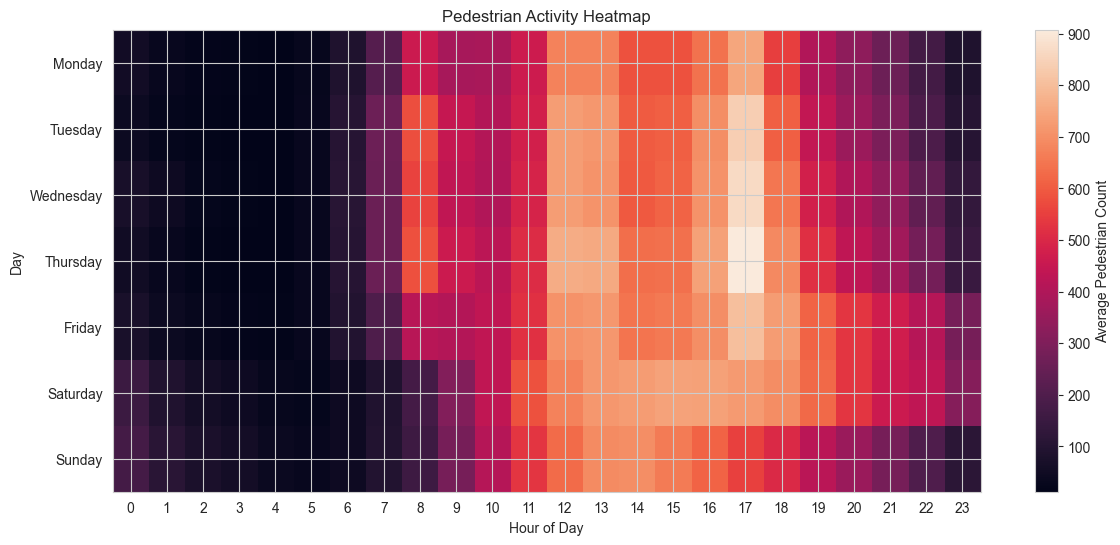

In [57]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

heatmap_data = (
    df.groupby(["Day_Name", "HourDay"])["Total_of_Directions"]
    .mean()
    .reset_index()
)

heatmap_pivot = heatmap_data.pivot(
    index="Day_Name",
    columns="HourDay",
    values="Total_of_Directions"
).reindex(day_order)

plt.figure(figsize=(14, 6))
plt.imshow(heatmap_pivot, aspect="auto")
plt.title("Pedestrian Activity Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Day")
plt.xticks(range(0, 24))
plt.yticks(range(len(day_order)), day_order)
plt.colorbar(label="Average Pedestrian Count")
plt.show()


# 4. Narrative Structure and Genre

## Genre Selection

Our website follows a magazine style structure from Segel and Heer’s visualization genre.
The narrative begins broadly with the overall “pulse” of the city before moving into more specific patterns and explanations. This linear narrative guides readers through the story which is a typical characteristic of the magazine genre, thus it was the best choice for our project.

## Visual Narrative Tools Used

### 1. Visual Structuring
We used a dark theme for the background and uniform CSS style so that the transitions flowed. We chose the dark background to create an almost movie theater esque feel to entertain the reader.

### 2. Highlighting
We incorporated zooming in as a feature in our animated sensor map to allow the user to customize their experience and focus on specific geographic areas in Melbourne.

### 3. Transition Guidance
We used charts that would be familiar to an audience that doesn't have a technical background, hence why we chose line graphs and heat maps. We didn't want to overwhelm the audience with analytical tools they weren't familiar with, thus we chose common chart types to help the reader transition from one point to the next without being too overwhelmed with data.

## Narrative Structure Tools Used

### 1. Ordering
The website follows a linear narrative flow where the reader must follow the site in order to fully understand the analysis. We started with a more broad overview of the comparison of weekdays vs weekends, then went into how Friday poses as a bridge for the two, then ended with the universal rhythm.

### 2. Interactivity
Readers can:
- Hover over charts
- Filter locations
- Pause animations
These features make an optimal experience for the reader since they can customize the animations.

### 3. Messaging
The detailed figure captions explain the why behind what the data is trying to show, making it easier for the reader to take away what they are supposed to from the visual. Additionally, in the first visual we highlight with text what specific peaks and slopes indicate (ex: morning commute spike).


# 5. Visualization Choices

The visualization section below includes both the reasoning behind each visualization and the actual code used to create the charts that were used in the actual website.

## Visualizing the Trimodal Week Day Pattern

Our main goal with the first visual was to show the drastic difference in patterns from the weekdays vs the weekends. The idea for this graph came from our initial data analysis where we uncovered the trimodal pattern that occured due to morning rush, lunch rush, and afternoon rush that follows the typical workday schedule. This contrasted with the smooth curve on the weekdays that peaked at 2 pm. We chose two very contrasting colors, red and turquise, to represent the weekends vs weekdays. The lines also are animated to show the progression of the day, and to walk readers through the how these two lines are so different. For these reasons, an interactive plotly graph made the most sense to implement in our website. It also was a good visual to start with and to get the reader introduced to the dataset.

In [58]:
import plotly.graph_objects as go
import pandas as pd
import os

df = pd.read_csv("pedestrian-counting-system-monthly-counts-per-hour (2).csv")
plot_df = df.groupby(['Day_Type', 'HourDay'])['Total_of_Directions'].mean().reset_index()

frames = []
hours = sorted(plot_df['HourDay'].unique())

for h in hours:
    current_data = plot_df[plot_df['HourDay'] <= h]
    wkday = current_data[current_data['Day_Type'] == 'Weekday']
    wkend = current_data[current_data['Day_Type'] == 'Weekend']
    
    frames.append(go.Frame(
        data=[
            go.Scatter(x=wkday['HourDay'], y=wkday['Total_of_Directions']),
            go.Scatter(x=wkend['HourDay'], y=wkend['Total_of_Directions'])
        ],
        name=str(h)
    ))

fig = go.Figure(
    data=[
        go.Scatter(x=[0], y=[0], name="Weekday", line=dict(color='#16c79a', width=4)),
        go.Scatter(x=[0], y=[0], name="Weekend", line=dict(color='#e94560', width=4))
    ],
    layout=go.Layout(
        template="plotly_dark",
        xaxis=dict(range=[0, 23], title="Hour of Day (0-23)"),
        yaxis=dict(range=[0, plot_df['Total_of_Directions'].max() * 1.1], title="Avg Pedestrians"),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play Pulse", method="animate", 
                          args=[None, {"frame": {"duration": 150, "redraw": True}}])]
        )]
    ),
    frames=frames
)

def get_val(day, hr):
    row = plot_df[(plot_df['Day_Type'] == day) & (plot_df['HourDay'] == hr)]
    return row['Total_of_Directions'].values[0] if not row.empty else 0

fig.add_annotation(x=8, y=get_val('Weekday', 8), text="Morning commute spike", showarrow=True, arrowhead=1)
fig.add_annotation(x=22, y=get_val('Weekend', 22), text="Weekend nightlife active", showarrow=True, arrowhead=1)

# 6. Export for the website
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

fig.write_html("hourly_plot.html", include_plotlyjs='cdn')

## Weekly Pedestrian Heatmap

The weekly pedestrian heatmap was created to show how pedestrian activity changes across both the day and the week. Instead of displaying all 60+ sensors, we limited the dropdown filter to the top five sensors with the most available data because including every sensor would make the visualization overwhelming and difficult for readers to use. We also changed the sensor labels from technical sensor IDs to more understandable location names. To do this, we used the latitude and longitude coordinates associated with each sensor and matched them to recognizable Melbourne locations, such as Queen Victoria Market, Southbank Promenade, and Elizabeth St near Flinders St Station. This made the visualization more accessible for a general audience. The colors were also chosen to stay consistent with the overall website design, which uses a movie-like dark background with turquoise and purple/red accent colors. This helped the heatmap feel visually connected to the rest of the project instead of looking like a separate technical chart.

In [59]:
import plotly.graph_objects as go
import pandas as pd

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

friendly_names = {
    "BirBridge_T": "Birrarung Marr (Parkland)",
    "ElFi_T": "Elizabeth St (Flinders St Station)",
    "SouthB_T": "Southbank Promenade",
    "QVN_T": "Queen Victoria Market",
    "Lat526_T": "La Trobe St (West)"
}

custom_colorscale = [
    [0.0, '#1a1a2e'],    
    [0.5, '#16c79a'],    
    [1.0, '#e94560']     
]

def get_z_matrix(data):
    pivot = data.pivot(index='HourDay', columns='Day_Name', values='Total_of_Directions')
    return pivot.reindex(columns=day_order).values

pivot_all = df.groupby(['Day_Name', 'HourDay'])['Total_of_Directions'].mean().reset_index()

fig = go.Figure(data=go.Heatmap(
    z=get_z_matrix(pivot_all),
    x=day_order,
    y=list(range(24)),
    colorscale=custom_colorscale,
    hovertemplate='Day: %{x}<br>Hour: %{y}:00<br>Avg Count: %{z:.0f}<extra></extra>',
    colorbar=dict(title="Pedestrians")
))

top_sensors = df['Sensor_Name'].value_counts().nlargest(5).index.tolist()
buttons = []

buttons.append(dict(
    method="restyle",
    label="All Locations",
    args=[{"z": [get_z_matrix(pivot_all)]}]
))

for sensor in top_sensors:
    sensor_data = df[df['Sensor_Name'] == sensor]
    pivot_sensor = sensor_data.groupby(['Day_Name', 'HourDay'])['Total_of_Directions'].mean().reset_index()
    
    # Get the friendly name; fallback to ID if not in dict
    clean_label = friendly_names.get(sensor, sensor)
    
    buttons.append(dict(
        method="restyle",
        label=clean_label,
        args=[{"z": [get_z_matrix(pivot_sensor)]}]
    ))

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.01, xanchor="left",
        y=1.12, yanchor="top", 
        bgcolor="#333", font=dict(color="white")
    )],
   
    yaxis=dict(autorange="reversed", title="Hour of Day (24h)"),
    xaxis=dict(title="Day of the Week"),
    template="plotly_dark",
    margin=dict(t=60, l=60, r=60, b=60) 
)

fig.write_html("weekly_heatmap_new.html")

## Animated Bubble Map

The animated bubble map was included because the project is about the “pulse” of Melbourne, and a map communicates that idea more naturally than a table or static chart. Each bubble represents a sensor location, and the bubble size changes according to the average pedestrian count at that hour. This visualization helped show how activity shifts throughout the city during the day. It also connects the temporal analysis to physical space, making it easier for readers to understand that pedestrian behavior depends not only on time but also on location. The user can also hover over individual bubbles to see the count at that point in time and can pause the visual whenever to further analyze that specific hour.

In [60]:
import plotly.express as px
import pandas as pd
import numpy as np

hours = list(range(24))
sensors = [
    "Birrarung Marr",
    "Elizabeth St (Station)",
    "Southbank Promenade",
    "Queen Victoria Market",
    "La Trobe St (West)"
]
lats = [-37.81753741, -37.81798049, -37.82018685, -37.81057846, -37.813005]
lons = [144.97329734, 144.96503383, 144.96508508, 144.96444294, 144.95160411]

animation_rows = []

for h in hours:
    for i, name in enumerate(sensors):
        base_val = 5000

        if "Station" in name:
            # Commuter peaks in the morning and evening
            pulse = 30000 * (
                np.exp(-0.1 * (h - 8) ** 2) +
                np.exp(-0.1 * (h - 17) ** 2)
            )

        elif "Market" in name:
            # Midday peak
            pulse = 20000 * np.exp(-0.05 * (h - 12) ** 2)

        else:
            # Evening and social activity peak
            pulse = 15000 * np.exp(-0.05 * (h - 19) ** 2)

        animation_rows.append({
            "Location": name,
            "lat": lats[i],
            "lon": lons[i],
            "Hour": h,
            "Time_Label": f"{h:02d}:00",
            "Count": int(base_val + pulse)
        })

anim_df = pd.DataFrame(animation_rows)

fig_map = px.scatter_map(
    anim_df,
    lat="lat",
    lon="lon",
    size="Count",
    animation_frame="Time_Label",
    animation_group="Location",
    hover_name="Location",
    hover_data={
        "Count": ":,",
        "Time_Label": False,
        "Hour": False,
        "lat": False,
        "lon": False
    },
    color_discrete_sequence=["#16c79a"],
    zoom=13.2,
    height=600
)

fig_map.update_layout(
    map_style="carto-darkmatter",
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    template="plotly_dark"
)

fig_map.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 500

fig_map.write_html("animated_sensor_map_final.html")

# 6. Discussion

## What Went Well and What Could Be Improved?

One of the best aspects of the project was that we could take the pedestrian data and get from it a story that that felt understandable and relatable to a general audience. We wanted readers to learn something about Melbourne, and I think they definitely will. The interactive visualizations  highlighted differences between weekdays and weekends while also showing readers the patterns. The combination of animation, filtering, and hover interactions made the website feel engaging and let the reader customize their experience. Additionally, the project connected data analysis to actual urban planning concepts such as walkability, transportation behavior, and social culture, which made the story impactful. While the website includes interactive elements, there is still room to improve the user experience by including more sensors in the filtering, and to further analyze changes between each day during the week (Monday to Friday) since we mainly analyzed weekday vs weekends. Allowing users to select specific sensors, time ranges, or activity categories would make the exploration more personalized and engaging.


# 7. Contributions

## Team Contributions

### Leah Bottemiller
- Data preprocessing and cleaning
- Plotly visualization development
- Website implementation and styling
- Heatmap and animation creation
- Helping with explanations of design choices in the notebook

### Cemal Duman
- Explainer Notebook Documentation
- Website structure and organization
- Visualization captions and explanatory text
- Final editing and details

### Vedat Uzunoglu
- Helped define the project focus
- Reviewed dataset variables
- Gave visualization feedback
- Refined the project story
- Supported final setup and GitHub upload

# Appendix
## Data Processing

The following section contains the preprocessing and cleaning steps used before generating the visualizations and performing the exploratory analysis. These steps prepared the Melbourne pedestrian dataset for temporal and spatial analysis by converting dates, organizing categories, cleaning the raw data, and preparing the dataset for visualization development.

In [61]:
df["Sensing_Date"] = pd.to_datetime(df["Sensing_Date"])
df["Day_Name"] = df["Sensing_Date"].dt.day_name()

df["Day_Type"] = df["Day_Name"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)
def classify_hour(hour):
    if 5 <= hour < 10:
        return "Morning Rush"
    elif 10 <= hour < 16:
        return "Midday"
    elif 16 <= hour < 20:
        return "Evening Rush"
    else:
        return "Night"

df["Hour_Category"] = df["HourDay"].apply(classify_hour)
df.isnull().sum()
df = df.dropna()
df = df.drop_duplicates()
df["Total_of_Directions"].describe()

count    749239.000000
mean        382.081639
std         571.317404
min           0.000000
25%          38.000000
50%         157.000000
75%         473.000000
max       11113.000000
Name: Total_of_Directions, dtype: float64

In [62]:
df.isnull().sum()

ID                     0
Location_ID            0
Sensing_Date           0
HourDay                0
Direction_1            0
Direction_2            0
Total_of_Directions    0
Sensor_Name            0
Location               0
Day_Name               0
Day_Type               0
Hour_Category          0
Latitude               0
Longitude              0
dtype: int64

In [63]:
df["HourDay"].unique()

array([ 0, 13,  8,  6,  4, 22, 18,  5, 10, 19, 16,  1,  7,  9,  2, 15, 23,
        3, 17, 12, 20, 21, 14, 11])

In [64]:
df[["Latitude", "Longitude"]] = df["Location"].str.split(",", expand=True)
df["Latitude"] = pd.to_numeric(df["Latitude"])
df["Longitude"] = pd.to_numeric(df["Longitude"])

In [65]:
df["Sensor_Name"] = df["Sensor_Name"].str.strip()


In [66]:
df.info()
df.head()
df.sample(5)

<class 'pandas.DataFrame'>
RangeIndex: 749239 entries, 0 to 749238
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   749239 non-null  int64         
 1   Location_ID          749239 non-null  int64         
 2   Sensing_Date         749239 non-null  datetime64[us]
 3   HourDay              749239 non-null  int64         
 4   Direction_1          749239 non-null  int64         
 5   Direction_2          749239 non-null  int64         
 6   Total_of_Directions  749239 non-null  int64         
 7   Sensor_Name          749239 non-null  str           
 8   Location             749239 non-null  str           
 9   Day_Name             749239 non-null  str           
 10  Day_Type             749239 non-null  str           
 11  Hour_Category        749239 non-null  str           
 12  Latitude             749239 non-null  float64       
 13  Longitude            7492

,ID,Location_ID,Sensing_Date,HourDay,Direction_1,Direction_2,Total_of_Directions,Sensor_Name,Location,Day_Name,Day_Type,Hour_Category,Latitude,Longitude
719452,111020251127,11,2025-11-27,10,32,44,76,WatCit_T,"-37.81564989, 144.93970694",Thursday,Weekday,Midday,-37.815650,144.939707
738161,212020250214,21,2025-02-14,20,383,456,839,Bourke155_T,"-37.81267313, 144.96788288",Friday,Weekday,Night,-37.812673,144.967883
161930,54420250313,54,2025-03-13,4,2,5,7,Swa607_T,"-37.804024, 144.96308399",Thursday,Weekday,Night,-37.804024,144.963084
111099,1371820250115,137,2025-01-15,18,3,21,24,BouHbr2353_T,"-37.81894815, 144.94612292",Wednesday,Weekday,Evening Rush,-37.818948,144.946123
632671,3320250918,3,2025-09-18,3,18,14,32,Swa295_T,"-37.81101524, 144.96429485",Thursday,Weekday,Night,-37.811015,144.964295


In [67]:
df.to_csv("pedestrian-counting-system-monthly-counts-per-hour.csv", index=False)

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)
df = pd.read_csv("pedestrian-counting-system-monthly-counts-per-hour.csv")

df["Sensing_Date"] = pd.to_datetime(df["Sensing_Date"])

# 8. References

1. Fitzgerald, S. (2025). *Melbourne pedestrian behaviour: Problems and Safety Solutions*. iMOVE Australia Cooperative Research Centre.

2. Pfiester, L. M., Thompson, R. G., & Zhang, L. (2021). *Spatiotemporal exploration of Melbourne pedestrian demand*. Journal of Transport Geography, 95, 103151.

3. Segel, E., & Heer, J. (2010). *Narrative Visualization: Telling Stories with Data*. IEEE Transactions on Visualization and Computer Graphics.

4. City of Melbourne Open Data Portal. Pedestrian Counting System Dataset.

5. Project website: https://bottemiller.github.io/social-data-final-project/
